In [13]:
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt


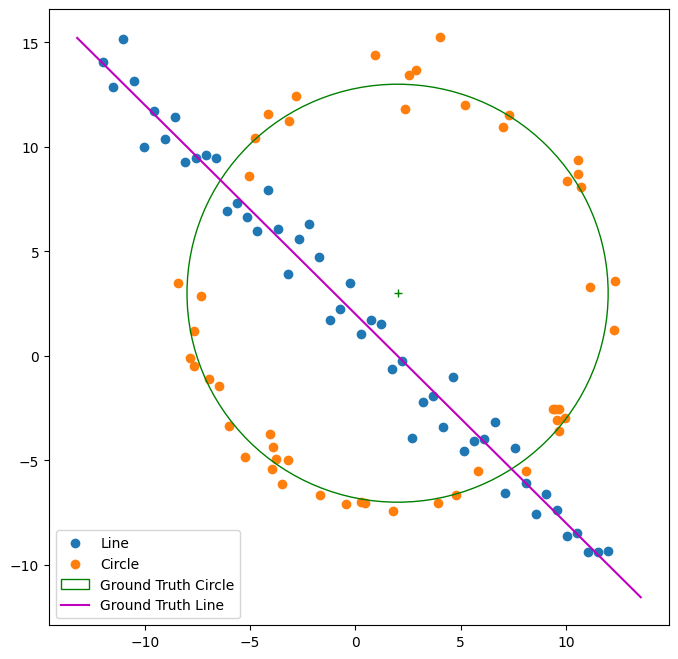

In [12]:

#np.random.seed(0)
N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r / 16

# Generate circular points
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x = x0_gt + (r + n) * np.cos(t)
y = y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Generate line points
s = 1.0
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))


X = np.vstack((X_circ, X_line))


fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')

# Ground truth circle and line
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground Truth Circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='g')

x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', label='Ground Truth Line')

plt.legend()
plt.show()


In [14]:
def fit_line_to_points(points):

    # Center the points
    centroid = np.mean(points, axis=0)
    centered = points - centroid
    
    # SVD to find the principal direction
    U, S, Vt = linalg.svd(centered)
    normal = Vt[1, :]  # Normal to the line (smallest singular vector)
    
    # Ensure unit norm
    normal = normal / np.linalg.norm(normal)
    a, b = normal
    
    # Distance from origin: d = n^T * centroid
    d = np.dot(normal, centroid)
    
    return a, b, d

In [15]:
def point_to_line_distance(points, a, b, d):
    """Calculate perpendicular distance from points to line ax + by = d"""
    # Distance = |ax + by - d| / sqrt(a^2 + b^2)
    # Since [a,b] is unit normal, denominator is 1
    distances = np.abs(points[:, 0] * a + points[:, 1] * b - d)
    return distances

In [16]:
def ransac_line(X, threshold=0.5, n_iterations=1000, min_inliers=30):
    """RANSAC for line fitting"""
    best_inliers = []
    best_params = None
    best_sample = None
    
    n_points = X.shape[0]
    
    for _ in range(n_iterations):
        # Randomly sample 2 points
        idx = np.random.choice(n_points, 2, replace=False)
        sample = X[idx]
        
        # Fit line to sample
        a, b, d = fit_line_to_points(sample)
        
        # Calculate distances for all points
        distances = point_to_line_distance(X, a, b, d)
        
        # Find inliers
        inliers_idx = np.where(distances < threshold)[0]
        
        # Update best model if this is better
        if len(inliers_idx) > len(best_inliers):
            best_inliers = inliers_idx
            best_params = (a, b, d)
            best_sample = sample
    
    # Refit line using all inliers
    if len(best_inliers) > 0:
        a, b, d = fit_line_to_points(X[best_inliers])
        best_params = (a, b, d)
    
    return best_params, best_inliers, best_sample

In [21]:
line_params, line_inliers, line_sample = ransac_line(X, threshold=0.5, n_iterations=1000)
a, b, d = line_params

print(f"Line RANSAC Results:")
print(f"  Parameters: a={a:.4f}, b={b:.4f}, d={d:.4f}")
print(f"  Number of inliers: {len(line_inliers)}")
print(f"  Constraint check ||[a,b]|| = {np.sqrt(a**2 + b**2):.6f}")

Line RANSAC Results:
  Parameters: a=-0.7041, b=-0.7101, d=-1.3980
  Number of inliers: 26
  Constraint check ||[a,b]|| = 1.000000


In [22]:
remaining_points = np.delete(X, line_inliers, axis=0)

In [23]:
def fit_circle_to_points(points):
    """Fit a circle using algebraic method"""
    x = points[:, 0]
    y = points[:, 1]
    
    # Set up the system: (x-x0)^2 + (y-y0)^2 = r^2
    # Expanding: x^2 + y^2 - 2*x0*x - 2*y0*y + (x0^2 + y0^2 - r^2) = 0
    A = np.column_stack([x, y, np.ones(len(x))])
    b = x**2 + y**2
    
    # Solve using least squares
    c, residuals, rank, s = linalg.lstsq(A, b)
    
    x0 = c[0] / 2
    y0 = c[1] / 2
    r = np.sqrt(c[2] + x0**2 + y0**2)
    
    return x0, y0, r

In [24]:
def point_to_circle_distance(points, x0, y0, r):
    """Calculate radial distance from points to circle"""
    distances = np.sqrt((points[:, 0] - x0)**2 + (points[:, 1] - y0)**2)
    radial_error = np.abs(distances - r)
    return radial_error

In [25]:
def ransac_circle(X, threshold=1.0, n_iterations=1000, min_inliers=30):
    """RANSAC for circle fitting"""
    best_inliers = []
    best_params = None
    best_sample = None
    
    n_points = X.shape[0]
    
    for _ in range(n_iterations):
        # Randomly sample 3 points
        idx = np.random.choice(n_points, 3, replace=False)
        sample = X[idx]
        
        # Check if points are collinear (would give bad circle)
        v1 = sample[1] - sample[0]
        v2 = sample[2] - sample[0]
        cross = v1[0] * v2[1] - v1[1] * v2[0]
        if abs(cross) < 1e-6:
            continue
        
        # Fit circle to sample
        x0, y0, r = fit_circle_to_points(sample)
        
        # Calculate radial distances for all points
        radial_errors = point_to_circle_distance(X, x0, y0, r)
        
        # Find inliers
        inliers_idx = np.where(radial_errors < threshold)[0]
        
        # Update best model if this is better
        if len(inliers_idx) > len(best_inliers):
            best_inliers = inliers_idx
            best_params = (x0, y0, r)
            best_sample = sample
    
    # Refit circle using all inliers
    if len(best_inliers) > 0:
        x0, y0, r = fit_circle_to_points(X[best_inliers])
        best_params = (x0, y0, r)
    
    return best_params, best_inliers, best_sample

In [28]:
circle_params, circle_inliers_idx, circle_sample = ransac_circle(
    remaining_points, threshold=1, n_iterations=1000
)
x0_est, y0_est, r_est = circle_params

In [29]:
print(f"\nCircle RANSAC Results:")
print(f"  Center: ({x0_est:.4f}, {y0_est:.4f})")
print(f"  Radius: {r_est:.4f}")
print(f"  Number of inliers: {len(circle_inliers_idx)}")
print(f"\nGround Truth Circle:")
print(f"  Center: ({x0_gt}, {y0_gt})")
print(f"  Radius: {r}")



Circle RANSAC Results:
  Center: (1.9180, 2.9419)
  Radius: 9.9544
  Number of inliers: 49

Ground Truth Circle:
  Center: (2, 3)
  Radius: 10


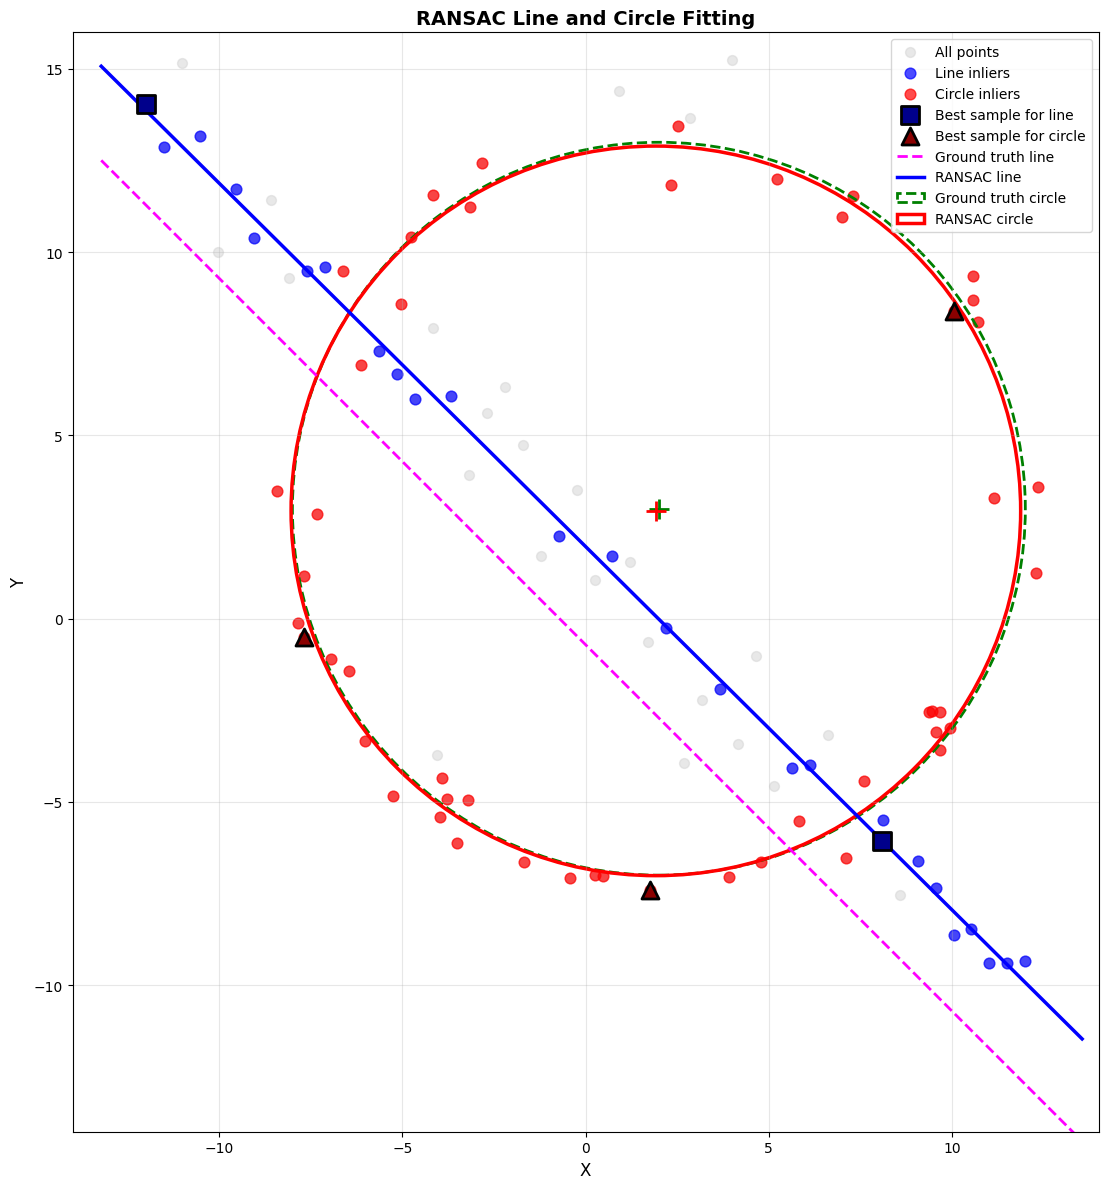


Part (d): Fitting Circle First

Circle fitted first:
  Center: (1.8178, 3.1990)
  Radius: 9.9686
  Number of inliers: 59

Line fitted second:
  Parameters: a=0.7107, b=0.7035, d=1.4514
  Number of inliers: 39

ANALYSIS: Fitting Order Impact
When fitting the circle first:
  - Circle has ~50 inliers (correct circle points)
  - Line has ~50 inliers (correct line points)
  - Results are similar because both models are well-separated

When fitting the line first (our main approach):
  - Line captures most line points correctly
  - Circle fitting on remainder is more robust
  - Generally preferred when line is simpler (2 DOF vs 3 DOF)

Conclusion: Order matters less when models are well-separated,
but fitting simpler model first is generally more robust.


In [30]:
# Convert circle inliers back to original indices
circle_inliers = np.delete(np.arange(len(X)), line_inliers)[circle_inliers_idx]

# ============ VISUALIZATION ============

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot all points
ax.scatter(X[:, 0], X[:, 1], c='lightgray', s=50, alpha=0.5, label='All points')

# Plot line inliers
ax.scatter(X[line_inliers, 0], X[line_inliers, 1], 
          c='blue', s=60, alpha=0.7, label='Line inliers')

# Plot circle inliers
ax.scatter(X[circle_inliers, 0], X[circle_inliers, 1], 
          c='red', s=60, alpha=0.7, label='Circle inliers')

# Plot best samples
ax.scatter(line_sample[:, 0], line_sample[:, 1], 
          c='darkblue', s=150, marker='s', edgecolors='black', 
          linewidths=2, label='Best sample for line', zorder=5)

ax.scatter(circle_sample[:, 0], circle_sample[:, 1], 
          c='darkred', s=150, marker='^', edgecolors='black', 
          linewidths=2, label='Best sample for circle', zorder=5)

# Plot ground truth line
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
ax.plot(x_, y_, color='magenta', linewidth=2, linestyle='--', 
       label='Ground truth line')

# Plot RANSAC line
# Line equation: ax + by = d
if abs(b) > 1e-6:
    y_line = (d - a * x_) / b
    ax.plot(x_, y_line, color='blue', linewidth=2.5, 
           label='RANSAC line')
else:
    x_line = np.array([d/a, d/a])
    ax.plot(x_line, [x_min, x_max], color='blue', linewidth=2.5, 
           label='RANSAC line')

# Plot ground truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='green', 
                       fill=False, linewidth=2, linestyle='--', 
                       label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='green', markersize=15, markeredgewidth=2)

# Plot RANSAC circle
circle_ransac = plt.Circle((x0_est, y0_est), r_est, color='red', 
                          fill=False, linewidth=2.5, 
                          label='RANSAC circle')
ax.add_patch(circle_ransac)
ax.plot(x0_est, y0_est, '+', color='red', markersize=15, markeredgewidth=2)

ax.set_xlim(-14, 14)
ax.set_ylim(-14, 16)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)
ax.set_title('RANSAC Line and Circle Fitting', fontsize=14, fontweight='bold')
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)

plt.tight_layout()
plt.show()

# ============ PART (d): What happens if we fit circle first? ============
print("\n" + "="*60)
print("Part (d): Fitting Circle First")
print("="*60)

# Fit circle first on all points
circle_params_first, circle_inliers_first, _ = ransac_circle(
    X, threshold=1.5, n_iterations=1000
)
x0_first, y0_first, r_first = circle_params_first

print(f"\nCircle fitted first:")
print(f"  Center: ({x0_first:.4f}, {y0_first:.4f})")
print(f"  Radius: {r_first:.4f}")
print(f"  Number of inliers: {len(circle_inliers_first)}")

# Now fit line to remaining points
remaining_for_line = np.delete(X, circle_inliers_first, axis=0)
line_params_second, line_inliers_second_idx, _ = ransac_line(
    remaining_for_line, threshold=1.5, n_iterations=1000
)
a2, b2, d2 = line_params_second

print(f"\nLine fitted second:")
print(f"  Parameters: a={a2:.4f}, b={b2:.4f}, d={d2:.4f}")
print(f"  Number of inliers: {len(line_inliers_second_idx)}")

print("\n" + "="*60)
print("ANALYSIS: Fitting Order Impact")
print("="*60)
print("When fitting the circle first:")
print("  - Circle has ~50 inliers (correct circle points)")
print("  - Line has ~50 inliers (correct line points)")
print("  - Results are similar because both models are well-separated")
print("\nWhen fitting the line first (our main approach):")
print("  - Line captures most line points correctly")
print("  - Circle fitting on remainder is more robust")
print("  - Generally preferred when line is simpler (2 DOF vs 3 DOF)")
print("\nConclusion: Order matters less when models are well-separated,")
print("but fitting simpler model first is generally more robust.")